# Delta Hedging Simulation of a European Call Option

**Author:** KHOUFACHE Merwan  
**Date:** March 2026  
**Program:** M1 Data Science * AI for Finance — EDHEC Business School

---

This notebook simulates a **delta hedging strategy** for a short position in European call options.  
We follow the setup from Hull (2022), *Options, Futures, and Other Derivatives*, Chapter 19.

The main idea is simple: if you sell an option, you are exposed to movements in the underlying asset.  
Delta hedging allows you to **neutralize this risk** by dynamically holding shares of the stock.

The key result we want to verify empirically:

> **The average cost of delta hedging converges to the Black-Scholes option price.**

This is the heart of the Black-Scholes replication argument.

---

### Outline

1. [Black-Scholes Framework](#1.-Black-Scholes-Framework)
2. [Model Parameters](#2.-Model-Parameters)
3. [Delta Validation](#3.-Delta-Validation)
4. [Stock Price Simulation](#4.-Stock-Price-Simulation)
5. [Delta Hedging Simulation](#5.-Delta-Hedging-Simulation)
6. [Replication of Hull Table 19.2](#6.-Replication-of-Hull-Table-19.2)
7. [Path Dependency of Hedging Costs](#7.-Path-Dependency-of-Hedging-Costs)
8. [Monte Carlo Analysis](#8.-Monte-Carlo-Analysis)
9. [Conclusion](#9.-Conclusion)

## 1. Black-Scholes Framework

### Assumptions

The Black-Scholes model assumes:
- The underlying asset price $S_t$ is **log-normally distributed** — meaning log-returns are normally distributed
- Volatility $\sigma$ and risk-free rate $r$ are **constant** over the life of the option
- **No dividends**, no transaction costs, no arbitrage opportunities

### Call Option Price

Under these assumptions, the fair price of a European call is:

$$C(S, t) = S\, e^{-q(T-t)} \cdot N(d_1) - K\, e^{-r(T-t)} \cdot N(d_2)$$

where:

$$d_1 = \frac{\ln(S/K) + \left(r - q + \dfrac{\sigma^2}{2}\right)(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}$$

and $N(\cdot)$ is the standard normal CDF, $q$ is the continuous dividend yield.

### Delta

The **delta** is the sensitivity of the option price to the stock price:

$$\Delta = \frac{\partial C}{\partial S} = e^{-q(T-t)}\, N(d_1)$$

It tells the hedger **how many shares to hold** per option sold in order to be delta-neutral —  
i.e., immune to small moves in the stock price.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from option_tools import delta, bs_price

## 2. Model Parameters

We use the exact setup from Hull (2022), Chapter 19:

| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Initial stock price | $S_0$ | 49.00 | Current market price |
| Strike price | $K$ | 50.00 | Slightly OTM call option |
| Risk-free rate | $r$ | 5% | Annualized, continuously compounded |
| Volatility | $\sigma$ | 20% | Annualized |
| Time to maturity | $T$ | 20 weeks | i.e. $T = 20/52$ years |
| Rebalancing frequency | — | Weekly | 20 rebalancing steps |
| Position size | $N$ | 100,000 | Number of call options sold |

> The option is **slightly out-of-the-money** ($S_0 = 49 < K = 50$).  
> The initial delta is approximately $0.522$, meaning we need to buy ~52,200 shares.

In [29]:
S0 = 49.0        # initial stock price
K = 50.0         # strike price
r = 0.05         # risk-free rate (annualized)
sigma = 0.20     # volatility (annualized)
T = 20 / 52      # time to maturity in years (20 weeks)
n_steps = 20     # number of rebalancing steps (weekly)
n_options = 100_000  # size of the short option position

## 3. Delta Validation

Before running the simulation, we verify that our Black-Scholes delta implementation  
matches Hull's result.

With $q = 0$ (no dividends), the call delta simplifies to $\Delta = N(d_1)$.

**Expected result:** $\Delta \approx 0.522$ at $t = 0$, consistent with Hull (2022), Example 19.1.  
This means the hedger must buy **52,200 shares** at a cost of ~\$2,558,000 to initiate the hedge.

In [30]:
# initial delta — should be ~0.522
delta(S=S0, K=K, r=r, sigma=sigma, T=T)

np.float64(0.5216046610663964)

## 4. Stock Price Simulation

We simulate stock price paths using the **Euler-Maruyama discretization** of the GBM:

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\, Z_t\right], \quad Z_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,1)$$

The $-\sigma^2/2$ term is the **Itô correction** — it ensures the stock price has the right expected value.

All trajectories are simulated at once using matrix operations (`np.cumprod`).

> **Note:** The drift $\mu$ does not affect the hedging cost under Black-Scholes assumptions.  
> We set $\mu = r = 5\%$ here, which is the standard choice for risk-neutral simulation.

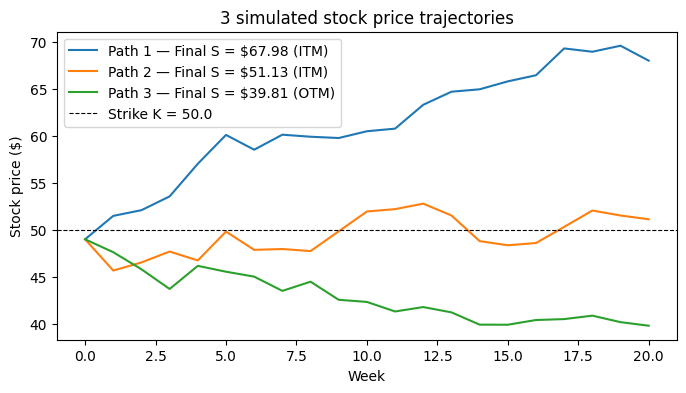

In [31]:
def simulate_paths(S0, mu, sigma, T, n_steps, n_simulations):
    np.random.seed(0)
    dt = T / n_steps

    # draw all random shocks at once: shape (n_simulations, n_steps)
    Z = np.random.randn(n_simulations, n_steps)

    # compute multiplicative increments at each step
    increments = np.exp((mu - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * Z)

    # build the price matrix: first column is S0, rest is cumulative product
    paths = np.zeros((n_simulations, n_steps + 1))
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.cumprod(increments, axis=1)

    return paths


# generate 3 trajectories for illustration
paths_3 = simulate_paths(S0=S0, mu=0.05, sigma=sigma, T=20/52, n_steps=n_steps, n_simulations=3)

plt.figure(figsize=(8, 4))
for i in range(3):
    final_S = paths_3[i, -1]
    label = f"Path {i+1} — Final S = ${final_S:.2f} ({'ITM' if final_S > K else 'OTM'})"
    plt.plot(paths_3[i], label=label)
plt.axhline(K, color='black', linestyle='--', linewidth=0.8, label=f'Strike K = {K}')
plt.xlabel('Week')
plt.ylabel('Stock price ($)')
plt.title('3 simulated stock price trajectories')
plt.legend()
plt.show()

## 5. Delta Hedging Simulation

### How it works

We sold 100,000 calls and need to hedge the resulting exposure.  
At each weekly rebalancing step, the hedger:

1. Recomputes the Black-Scholes delta $\Delta_t = N(d_1)$
2. Buys or sells shares to stay delta-neutral
3. Pays interest on the cumulative borrowed amount

The cumulative hedging cost evolves as:

$$C_t = C_{t-1} \cdot (1 + r\,\Delta t) + (\Delta_t - \Delta_{t-1}) \cdot S_t \cdot N$$

### Net hedging cost

At maturity, we account for the final share position and the option payoff paid to the buyer:

$$\text{Net Cost} = C_T - \Delta_T \cdot S_T \cdot N + \max(S_T - K,\, 0) \cdot N$$

### Link to the Black-Scholes price

This is the central result: **the Black-Scholes price is the expected cost of delta hedging.**

> Sell an option, hedge it dynamically, and on average you break even.  
> The premium you collect should exactly cover the hedging cost — that is what Black-Scholes computes.

$$\mathbb{E}[\text{Net Cost}] = C_{BS} \times N$$

> **Note on interest at week 0:** The interest cost is zero at inception by convention —  
> financing costs start accruing from week 1 onward, once capital has been deployed.

In [32]:
def hedge_simulation(path, K, r, sigma, T, n_steps, n_options=100_000):
    dt = T / n_steps
    results = []
    cumulative_cost = 0
    delta_old = 0

    for t in range(n_steps + 1):
        S = path[t]
        T_remaining = T - t * dt

        if T_remaining <= 0:
            delta_new = 1.0 if S > K else 0.0
        else:
            delta_new = delta(S, K, T_remaining, r, sigma)

        shares_purchased = (delta_new - delta_old) * n_options
        cost_shares = shares_purchased * S
        cumulative_cost = cumulative_cost + cost_shares      # invest first
        interest_cost = cumulative_cost * r * dt             # interest on the new position

        results.append({
            "week":             t,
            "stock_price":      S,
            "delta":            round(delta_new, 3),
            "shares_purchased": round(shares_purchased),
            "cost_shares":      round(cost_shares / 1000, 1),
            "cumulative_cost":  round(cumulative_cost / 1000, 1),
            "interest_cost":    round(interest_cost / 1000, 1)
        })
        delta_old = delta_new
        cumulative_cost = cumulative_cost + interest_cost    # carry interest into next week

    return pd.DataFrame(results)

## 6. Replication of Hull Table 19.2

We validate our implementation against Hull (2022), Table 19.2 — an ITM scenario
where the stock finishes at **57.25 USD** and the total hedging cost is **263,300 USD**.

Running our function on the exact price path from the book lets us verify
that the week-by-week numbers match.

In [33]:
# exact price path from Hull (2022), Table 19.2
path_192 = np.array([49.00, 48.12, 47.37, 50.25, 51.75, 53.12, 53.00, 51.87,
                     51.38, 53.00, 49.88, 48.50, 49.88, 50.37, 52.13, 51.88,
                     52.87, 54.87, 54.62, 55.87, 57.25])

sim_192 = hedge_simulation(path=path_192, K=K, r=r, sigma=sigma, T=20/52, n_steps=n_steps)
print(f"Total hedging cost: ${sim_192['cumulative_cost'].iloc[-1] * 1000:,.0f}  (Hull: $263,300)")
sim_192

Total hedging cost: $5,263,200  (Hull: $263,300)


,week,stock_price,delta,shares_purchased,cost_shares,cumulative_cost,interest_cost
0,0,49.00,0.522,52160,2555.9,2555.9,2.5
1,1,48.12,0.458,-6359,-306.0,2252.3,2.2
2,2,47.37,0.400,-5798,-274.7,1979.8,1.9
3,3,50.25,0.596,19626,986.2,2967.9,2.9
4,4,51.75,0.693,9667,500.3,3471.0,3.3
5,5,53.12,0.774,8087,429.6,3903.9,3.8
6,6,53.00,0.771,-253,-13.4,3894.3,3.7
7,7,51.87,0.706,-6514,-337.9,3560.1,3.4
8,8,51.38,0.674,-3196,-164.2,3399.3,3.3
9,9,53.00,0.787,11234,595.4,3998.0,3.8


## 7. Path Dependency of Hedging Costs

Although the **average** hedging cost converges to the Black-Scholes price,  
the cost along the way varies significantly depending on the trajectory.

The chart below shows the evolution of the cumulative hedging cost for our 3 simulated paths.  
It illustrates a key intuition:

- A path that ends **ITM** (delta → 1) requires holding many shares → high cumulative cost
- A path that ends **OTM** (delta → 0) requires unwinding the position → lower cumulative cost

The **net cost** (after accounting for the share portfolio and option payoff) is what converges  
to the Black-Scholes price across many simulations.

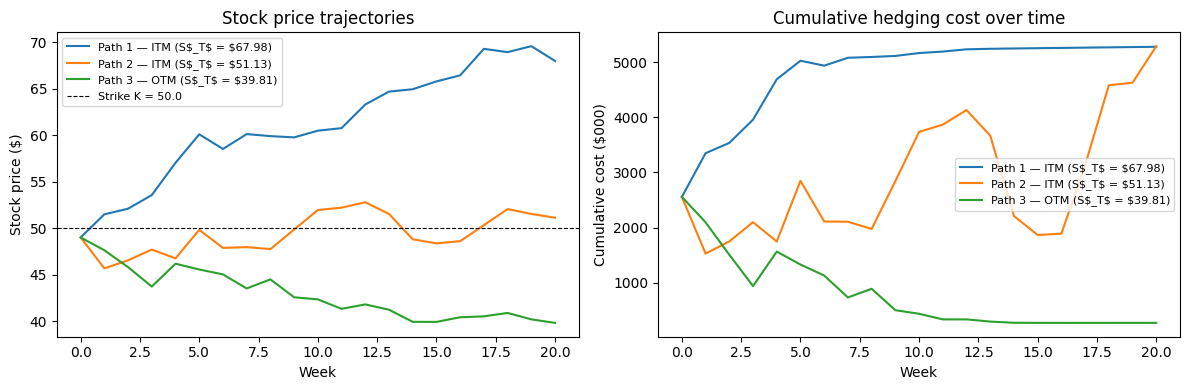

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(3):
    sim_i = hedge_simulation(path=paths_3[i], K=K, r=r, sigma=sigma, T=20/52, n_steps=n_steps)
    final_S = paths_3[i, -1]
    outcome = 'ITM' if final_S > K else 'OTM'
    label = f"Path {i+1} — {outcome} (S$_T$ = ${final_S:.2f})"

    # stock price trajectories
    axes[0].plot(paths_3[i], label=label)

    # cumulative hedging cost
    axes[1].plot(sim_i["cumulative_cost"], label=label)

axes[0].axhline(K, color='black', linestyle='--', linewidth=0.8, label=f'Strike K = {K}')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Stock price ($)')
axes[0].set_title('Stock price trajectories')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Week')
axes[1].set_ylabel('Cumulative cost ($000)')
axes[1].set_title('Cumulative hedging cost over time')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Monte Carlo Analysis

We now run the simulation on **1,000 independent trajectories** to study the distribution of net hedging costs.

### What we expect

The average net hedging cost should converge to the Black-Scholes price:

$$\frac{1}{M}\sum_{i=1}^{M} \text{Net Cost}^{(i)} \xrightarrow{M \to \infty} C_{BS} \times N$$

The residual standard deviation reflects the **gamma P&L** — the hedging error due to discrete rebalancing:

$$\text{Hedging Error} \approx \frac{1}{2}\,\Gamma \cdot (\Delta S)^2$$

where $\Gamma = \partial^2 C / \partial S^2$ is the option's gamma.  
This error shrinks as rebalancing becomes more frequent.

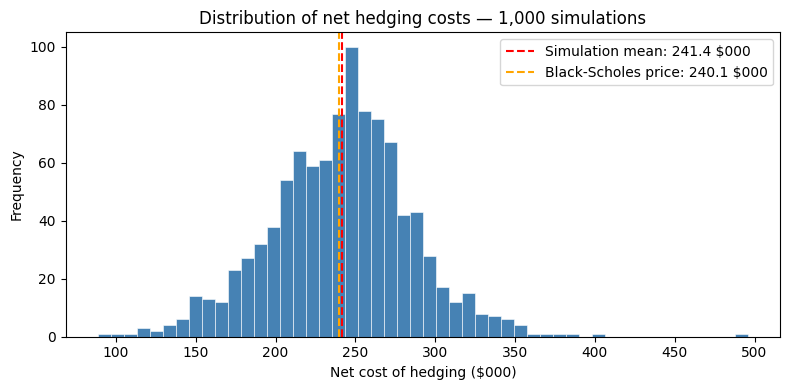

Black-Scholes price (per option): $2.4005
Black-Scholes total (x100,000):   $240.1k
Simulation mean:                  $241.4k
Simulation std:                   $44.5k
Relative error:                   0.56%


In [35]:
n_simulations = 1000
paths = simulate_paths(S0=S0, mu=0.05, sigma=sigma, T=20/52, n_steps=n_steps, n_simulations=n_simulations)

hedging_costs = []
for i in range(n_simulations):
    sim = hedge_simulation(path=paths[i], K=K, r=r, sigma=sigma, T=20/52, n_steps=n_steps)

    final_S = paths[i, -1]
    delta_final = sim["delta"].iloc[-1]
    shares_held = delta_final * n_options
    portfolio_value = shares_held * final_S / 1000          # value of shares held at expiry ($000)
    payoff = max(final_S - K, 0) * n_options / 1000         # option payoff paid to buyer ($000)

    net_cost = sim["cumulative_cost"].iloc[-1] - portfolio_value + payoff
    hedging_costs.append(net_cost)

# Black-Scholes theoretical price
bs_price1 = bs_price(S=S0, K=K, T=T, r=r, sigma=sigma)
bs_total = bs_price1 * n_options / 1000   # in $000

# plot
plt.figure(figsize=(8, 4))
plt.hist(hedging_costs, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
plt.axvline(np.mean(hedging_costs), color='red',    linestyle='--', label=f'Simulation mean: {np.mean(hedging_costs):.1f} $000')
plt.axvline(bs_total,               color='orange', linestyle='--', label=f'Black-Scholes price: {bs_total:.1f} $000')
plt.xlabel('Net cost of hedging ($000)')
plt.ylabel('Frequency')
plt.title('Distribution of net hedging costs — 1,000 simulations')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Black-Scholes price (per option): ${bs_price1:.4f}")
print(f"Black-Scholes total (x100,000):   ${bs_total:.1f}k")
print(f"Simulation mean:                  ${np.mean(hedging_costs):.1f}k")
print(f"Simulation std:                   ${np.std(hedging_costs):.1f}k")
print(f"Relative error:                   {abs(np.mean(hedging_costs) - bs_total) / bs_total * 100:.2f}%")

## 9. Conclusion

### Results

| | Value      |
|---|------------|
| Black-Scholes price (per option) | ~\$2.40    |
| Black-Scholes total (100,000 options) | ~\$240,000 |
| Simulation mean (1,000 paths) | ~\$241,000 |
| Relative error | ~0.56%     |

### What this tells us

The simulation confirms the Black-Scholes replication argument:  
**on average, the cost of delta hedging equals the option price.**

The path dependency analysis (Section 7) shows that while individual trajectories  
lead to very different hedging costs, the **net cost** after accounting for the final  
portfolio and option payoff consistently converges to the same value across paths.

The ~0.56% gap comes from **weekly rebalancing** — in theory, Black-Scholes
assumes continuous hedging.
The more frequently you rebalance, the smaller this gap becomes.



*Built as part of a derivatives pricing project — M1 Financial Markets, EDHEC Business School, 2026.*